<a href="https://colab.research.google.com/github/jeffwongqy/XAI-ML-for-Obesity-Risk-Classification/blob/main/obesity_risk_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier

# **Preprocessing Stages**

In [47]:
filepath = "/content/drive/MyDrive/XAI ML Obesity Risk Classification/obesity_data.csv"
obesity_df = pd.read_csv(filepath)
obesity_df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [48]:
obesity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

## **Missing Values**

In [49]:
obesity_df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


## **Duplicated Rows**

In [50]:
print(obesity_df.duplicated().sum())

24


In [51]:
obesity_df.drop_duplicates(inplace = True)

In [52]:
print(obesity_df.duplicated().sum())

0


## **Outliers**

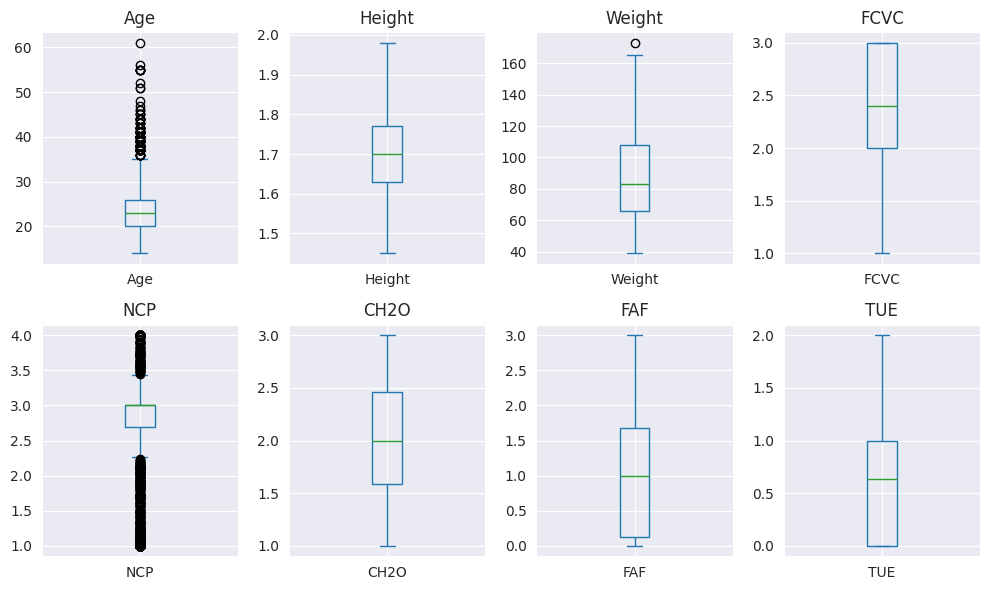

In [53]:
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.subplot(2, 4, 1)
obesity_df['Age'].plot(kind = "box")
plt.title("Age")

plt.subplot(2, 4, 2)
obesity_df['Height'].plot(kind = "box")
plt.title("Height")

plt.subplot(2, 4, 3)
obesity_df['Weight'].plot(kind = "box")
plt.title("Weight")

plt.subplot(2, 4, 4)
obesity_df['FCVC'].plot(kind = "box")
plt.title("FCVC")

plt.subplot(2, 4, 5)
obesity_df['NCP'].plot(kind = "box")
plt.title("NCP")

plt.subplot(2, 4, 6)
obesity_df['CH2O'].plot(kind = "box")
plt.title("CH2O")

plt.subplot(2, 4, 7)
obesity_df['FAF'].plot(kind = "box")
plt.title("FAF")

plt.subplot(2, 4, 8)
obesity_df['TUE'].plot(kind = "box")
plt.title("TUE")

plt.tight_layout()
plt.show()

In [54]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Q1 = obesity_df[num_cols].quantile(0.25)
Q3 = obesity_df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

obesity_df = obesity_df[~((obesity_df[num_cols] < lower_bound) | (obesity_df[num_cols] > upper_bound)).any(axis = 1)]

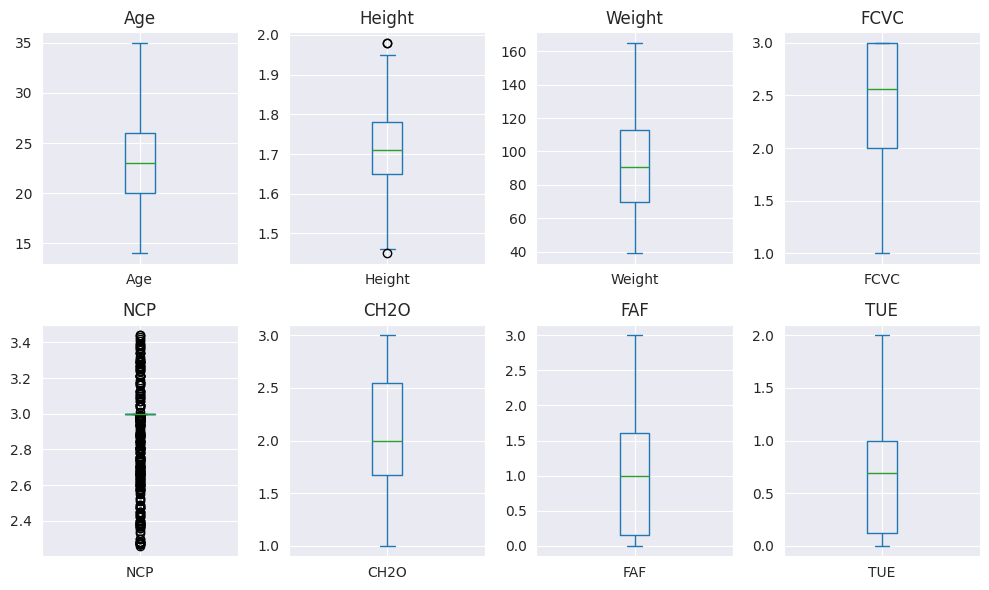

In [55]:
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.subplot(2, 4, 1)
obesity_df['Age'].plot(kind = "box")
plt.title("Age")

plt.subplot(2, 4, 2)
obesity_df['Height'].plot(kind = "box")
plt.title("Height")

plt.subplot(2, 4, 3)
obesity_df['Weight'].plot(kind = "box")
plt.title("Weight")

plt.subplot(2, 4, 4)
obesity_df['FCVC'].plot(kind = "box")
plt.title("FCVC")

plt.subplot(2, 4, 5)
obesity_df['NCP'].plot(kind = "box")
plt.title("NCP")

plt.subplot(2, 4, 6)
obesity_df['CH2O'].plot(kind = "box")
plt.title("CH2O")

plt.subplot(2, 4, 7)
obesity_df['FAF'].plot(kind = "box")
plt.title("FAF")

plt.subplot(2, 4, 8)
obesity_df['TUE'].plot(kind = "box")
plt.title("TUE")

plt.tight_layout()
plt.show()

## **Data Mapping**

In [56]:
def gender_label_encoding(data):
  if data == "Male":
    return 0
  else:
    return 1

obesity_df['Gender'] = obesity_df['Gender'].apply(gender_label_encoding)

In [57]:
def family_history_label_encoding(data):
  if data == "no":
    return 0
  else:
    return 1

obesity_df['family_history_with_overweight'] = obesity_df['family_history_with_overweight'].apply(family_history_label_encoding)

In [58]:
def favc_label_encoding(data):
  if data == "no":
    return 0
  else:
    return 1

obesity_df['FAVC'] = obesity_df['FAVC'].apply(favc_label_encoding)

In [59]:
def caec_label_encoding(data):
  if data == "no":
    return 0
  elif data == "Sometimes":
    return 1
  elif data == "Frequently":
    return 2
  else:
    return 3

obesity_df['CAEC'] = obesity_df['CAEC'].apply(caec_label_encoding)


In [60]:
def smoke_label_encoding(data):
  if data == "no":
    return 0
  else:
    return 1

obesity_df['SMOKE'] = obesity_df['SMOKE'].apply(smoke_label_encoding)

In [61]:
def scc_label_encoding(data):
  if data == "no":
    return 0
  else:
    return 1

obesity_df['SCC'] = obesity_df['SCC'].apply(scc_label_encoding)

In [62]:
def calc_label_encoding(data):
  if data == "no":
    return 0
  elif data == "Sometimes":
    return 1
  elif data == "Frequently":
    return 2
  else:
    return 3

obesity_df['CALC'] = obesity_df['CALC'].apply(calc_label_encoding)

In [63]:
def mtrans_label_encoding(data):
  if data == "Automobile":
    return 0
  elif data == "Motorbike":
    return 1
  elif data == "Bike":
    return 2
  elif data == "Public_Transportation":
    return 3
  else:
    return 4

obesity_df['MTRANS'] = obesity_df['MTRANS'].apply(mtrans_label_encoding)

In [64]:
def target_label_encoding(data):
  if data == "Insufficient_Weight":
    return 0
  elif data == "Normal_Weight":
    return 1
  elif data == "Overweight_Level_I":
    return 2
  elif data == "Overweight_Level_II":
    return 3
  elif data == "Obesity_Type_I":
    return 4
  elif data == "Obesity_Type_II":
    return 5
  else:
    return 6

obesity_df['NObeyesdad'] = obesity_df['NObeyesdad'].apply(target_label_encoding)

In [65]:
obesity_df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,1,21,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,3,1
1,1,21,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,3,1
2,0,23,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,3,1
3,0,27,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,4,2
5,0,29,1.62,53.0,0,1,2.0,3.0,1,0,2.0,0,0.0,0.0,1,0,1


## **Data Splitting**

In [66]:
X_train, X_test, y_train, y_test = train_test_split(obesity_df.drop(columns = ['NObeyesdad'], axis = 1),
                                                    obesity_df['NObeyesdad'],
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    shuffle = True,
                                                    stratify = obesity_df['NObeyesdad'])

## **Data Normalization**

In [67]:
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [68]:
X_train.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
720,1,0.380952,0.500000,0.099080,1,1,0.745,0.623932,2,0,0.030,0,0.736667,0.9790,0,3
1118,1,0.190476,0.153846,0.260194,1,0,1.000,0.700855,1,0,0.500,0,0.466667,0.5000,0,3
1636,0,0.619048,0.634615,0.628034,1,1,0.500,0.623932,1,0,0.670,0,0.300000,0.0405,1,3
677,1,0.285714,0.423077,0.080200,0,0,0.860,0.623932,1,0,0.500,0,0.620000,0.5000,1,3
1903,1,0.238095,0.500000,0.703157,1,1,1.000,0.623932,1,0,0.155,0,0.303333,0.3535,1,3


## **Feature Selection**

In [81]:
lasso_cv = LassoCV(cv = 5, random_state = 42)
lasso_cv.fit(X_train, y_train)

LassoCV(cv=5, random_state=42)

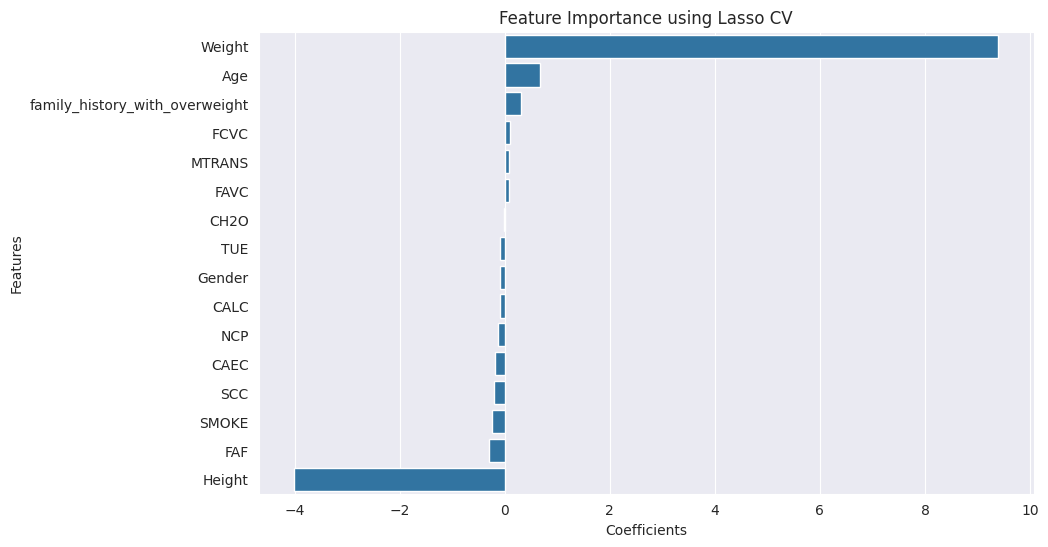

In [85]:
coef_df = pd.DataFrame({'Features': X_train.columns, 'Coefficients': lasso_cv.coef_})
coef_df.sort_values(by = "Coefficients", ascending = False, inplace = True)

plt.figure(figsize = (10, 6))
sns.barplot(x = "Coefficients", y = "Features", data = coef_df)
plt.title("Feature Importance using Lasso CV")
plt.show()

In [88]:
X_train = X_train[coef_df[coef_df['Coefficients'] != 0]['Features']]
X_test = X_test[coef_df[coef_df['Coefficients'] != 0]['Features']]

## **Data Balancing**

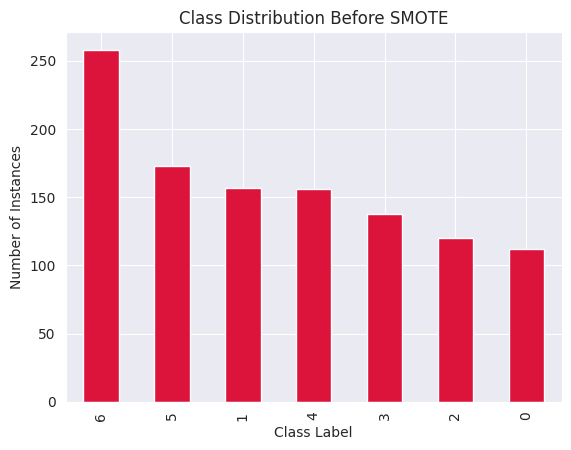

In [101]:
y_train.value_counts().plot(kind = "bar", color = "crimson")
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class Label")
plt.ylabel("Number of Instances")
plt.show()

In [102]:
smt = SMOTE()
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

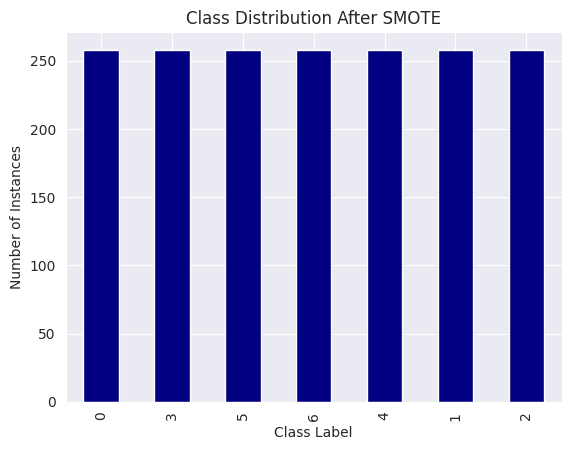

In [107]:
y_train_res.value_counts().plot(kind = "bar", color = "navy")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class Label")
plt.ylabel("Number of Instances")
plt.show()

# **Training Process**

# **Evaluation**